# Introduction to Scientific Computing

[Acknowledgments](#Acknowledgments)

In this course we will explore a number of physics problems and numerical approaches to solving them. We will strive to understand the fundamentals and to appreciate the mathematical and computational similarities between some disparate physics applications. 

In this notebook we will explore a simple numerical problem, staying attuned to some aspects of the problem that will arise again and again!

## A First Numerical Problem: Radioactive Decay

Consider the radioactive decay of an unstable isotope like $^{235}\mathrm{U}$, i.e., uranium nuclei with 92 protons and 143 neutrons. Each nucleus has a small, but significant, probability of decaying into two smaller nuclei. If we have some number of uranium nuclei at time $t$ given by $N_U(t)$, and the decay time constant is $\tau$, the number of uranium nuclei is governed by the equation

$$\frac{d N_U}{dt} = -\frac{N_U}{\tau}$$

where $\tau \sim 10^9$ for $^{235}\mathrm{U}$.

&#128310; What type of equation is this?

Differential equation

You have encountered this equation before, and you can solve it analytically:

$$N_U = N_U(0) e^{-t/\tau}$$

&#128310; Describe this equation in words. What does the quantity $N_U(0)$ represent?

N_U(0) represents the initial number of uranium nuclei at time t=0. The equation shows that the number of uranium nuclei decreases exponentially over time, with the decay rate determined by the time constant tau.

Radioactive decay thus represents a useful first problem for us to consider numerically, because we know the analytic solution and will be able to compare our numerical solution to it. So, how would we approach solving this differential equation numerically? 

Let's start by stating the problem in words. Our goal is to obtain $N_U$ as a function of $t$. Given the value of $N_U$ at some particular time like $t=0$, we want to estimate its value at later times.

Because we will start with a value and estimate values at later times, this is what's known as an **initial value problem**. We will explore these further in this course. Our approach here will be to realize that if we start with a given $N_U$ and we are able to estimate $N_U(\Delta t)$, i.e. $N_U$ a short time $\Delta t$ later, then we have only to repeat that process some number of times until we reach $N_U$ at the $t$ of interest.

Let's consider the definition of a derivative:

$$\frac{dx}{dt} = \lim_{\Delta t \rightarrow 0} \frac{x(t + \Delta t) - x(t)}{\Delta t}$$

In a computer, there's no taking $\Delta t \rightarrow 0$: we are dealing with discrete processes. We can, however, assume that $\Delta t$ is small enough that

$$\frac{dx}{dt} \approx \frac{x(t + \Delta t) - x(t)}{\Delta t}$$

Let's rearrange this to find our approximation for $x$ at time $t + \Delta t$:

$$ x(t + \Delta t) = x(t) + \frac{dx}{dt} \Delta t $$

&#128310; Describe this equation in words.

This equation tells us how to estimate the value of x at a future time (t + deltat t) based on its current value at time t and its current derivative. We take the current value and add the change that would occur over the small time interval delta t.

Another way to see this is to Taylor expand:

$$x(t + \Delta t) = x(t) + \frac{dx}{dt}\Delta t + \frac{1}{2}(\Delta t)^2 \frac{d^2x}{dt^2} + ...$$

and then truncate, where if $\Delta t$ is small enough, we can drop the $\mathcal{O} (\Delta t)^2$ terms. 

Recalling our linear system $\frac{dN_U}{dt} = -\frac{1}{\tau} N_U $, we write

$$ N_U(t + \Delta t) = N_U(t) - \frac{1}{\tau} N_U(t) \Delta t $$

We will find it useful to index our timesteps. Let's consider time $t$ to be timestep $k$, and time $t + \Delta t$ to be $k+1$. (And let's drop the $U$ subscript on $N_U$ to keep this notation clean.)

$$ N_{k+1} = N_k - \frac{1}{\tau} \Delta t N_k$$

Now we have a recipe for evolving our system from timestep $k$ to timestep $k+1$. Let's code it up.

&#128310; What inputs will a function returning $N_{k+1}$ need?

The function will need N_k (current value), delta t (the time step size), and tau (the decay constant).

&#128309; Import numpy and matplotlib.pyplot, and alias them as np and plt

In [2]:
import numpy as np
import matplotlib.pyplot as plt

&#128309; Write a function that takes $N_k$ and returns $N_{k+1}$. 

In [3]:
def evolve(N_k, delta_t, tau):
    return N_k - (1/tau) * delta_t * N_k

Congratulations! You have just written your own implementation of what's known as **Euler's method** (or the "forward Euler method"). Of course, you've written this for the specific ODE defined above. Generalize to the differential equation 
$$ \frac{dx}{dt} = f(x, t) $$
and write the expression for Euler's method as an expression for $x(t + \Delta t)$ below.

&#128309; Write a more general implementation of Euler's method below, i.e. write a function that solves $\frac{dx}{dt} = f(x, t)$ using Euler's method. Also write a function that implements $f(x, t)$ for the radioactive decay problem. 

In [4]:
def euler_method(f, x0, t0, dt, n_steps):
    x = x0
    t = t0
    x_values = [x0]
    t_values = [t0]
    
    for i in range(n_steps):
        x = x + dt * f(x, t)
        t = t + dt
        x_values.append(x)
        t_values.append(t)
    
    return np.array(t_values), np.array(x_values)

def radioactive_decay(N, t, tau=1.0):
    return -N / tau

&#128310; Describe in either words or pseudocode how you will evolve your system in time using your functions.

We will call euler_method with the radioactive_decay function, initial conditions, timestep and number of steps. The function will iteratively apply Euler's formula to approximate the solution at each time point.

&#128309; Use your functions to solve the radioactive decay equation.

In [5]:

t_values, N_values = euler_method(radioactive_decay, 100, 0, 0.1, 100)

&#128309; Plot your solution for $N_U$ as a function of time, and plot the analytic solution on the same plot. 

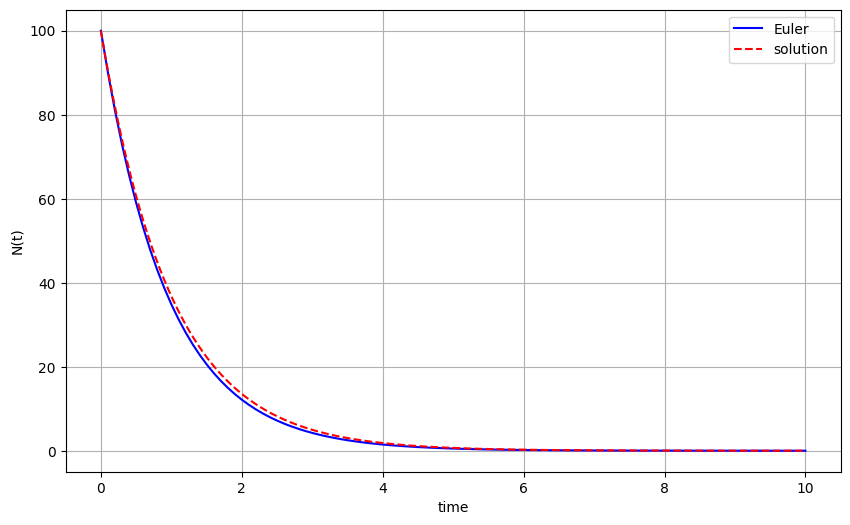

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(t_values, N_values, 'b-', label='Euler')
t_analytic = np.linspace(0, 10, 1000)
N_analytic = 100 * np.exp(-t_analytic)
plt.plot(t_analytic, N_analytic, 'r--', label='solution')
plt.xlabel('time')
plt.ylabel('N(t)')
plt.legend()
plt.grid(True)
plt.show()

&#128310; Describe the results in words. Do the outputs look reasonable?  

The Euler method solution closely matches the analytical solution for radioactive decay. The numerical approximation follows the expected exponential decay curve, so Euler provides a reasonable approximation for this differential equation at that timestep.

&#128310; Experiment with different timesteps and describe the results here. 

When experimenting with different timesteps, smaller timesteps (like 0.01) provide more accurate solutions that closely match the analytical result, while larger timesteps (like 0.5 or 1.0) introduce significant errors and can cause the numerical solution to deviate substantially from the true exponential decay. The accuracy improves as the timestep decreases but at the cost of increased computational time since more steps are required.

&#128309; Make a plot that clearly illustrates the effect of different timesteps on the accuracy of the solution. Describe the takeaways from your plot below it.

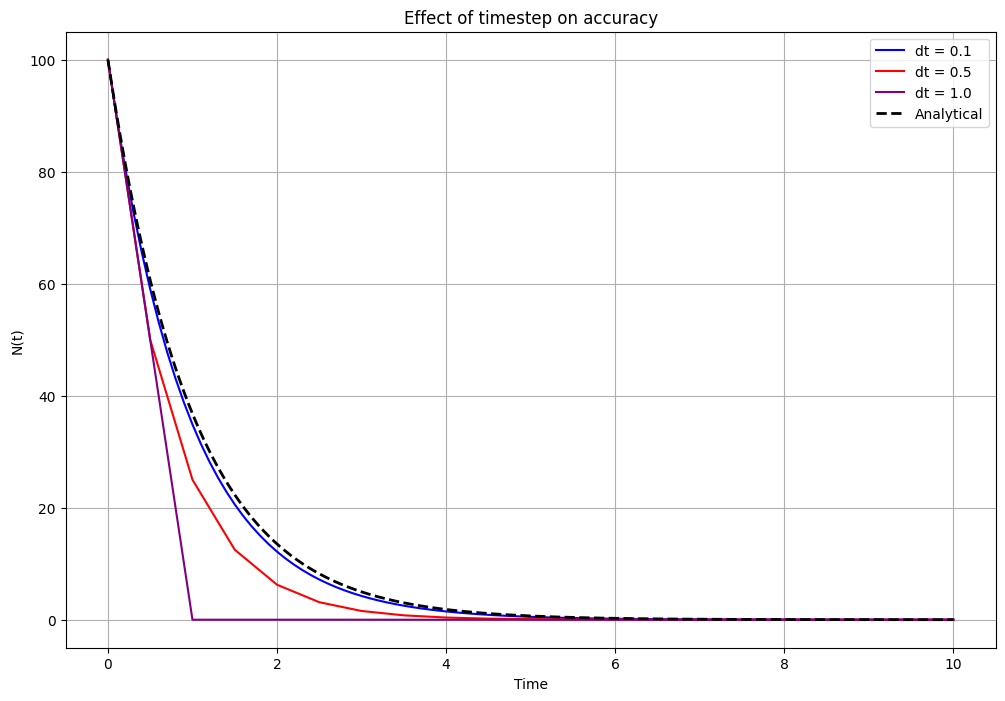

In [8]:
plt.figure(figsize=(12, 8))

timesteps = [0.1, 0.5, 1.0]
colors = ['blue', 'red', 'purple']

for i, dt in enumerate(timesteps):
    t_vals, N_vals = euler_method(radioactive_decay, 100, 0, dt, int(10/dt))
    plt.plot(t_vals, N_vals, color=colors[i], label=f'dt = {dt}')

t_analytic = np.linspace(0, 10, 1000)
N_analytic = 100 * np.exp(-t_analytic)
plt.plot(t_analytic, N_analytic, 'k--', linewidth=2, label='Analytical')

plt.xlabel('Time')
plt.ylabel('N(t)')
plt.legend()
plt.grid(True)
plt.title('Effect of timestep on accuracy')
plt.show()

The plot shows that smaller timesteps give more accurate results. As timestep increases, the error becomes larger and the solution deviates significantly from the true exponential decay. Smaller timesteps require more computation but give better accuracy.

&#128309; Use your implementation of Euler's method to solve the differential equation 

$$\frac{dx}{dt} = -x^3 + \sin t$$

given the initial condition $x = 0$ at $t = 0$.

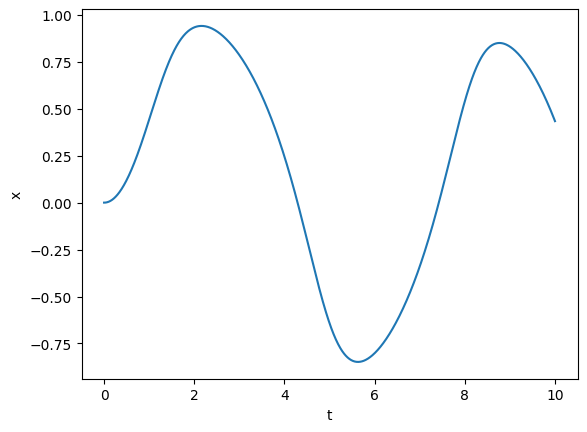

In [9]:
def nonlinear_ode(x, t):
    return -x**3 + np.sin(t)

t_vals, x_vals = euler_method(nonlinear_ode, 0, 0, 0.01, 1000)
plt.plot(t_vals, x_vals)
plt.xlabel('t')
plt.ylabel('x')
plt.show()

Euler's method is simple and intuitive, but as we will soon see, we never use it in practice. There are better methods for solving these types of problems, which we will soon explore together!

## Numerical Error

One theme that we will return to many times in this class is whether our chosen method is appropriate for our problem. To that end, we need to understand sources of error in our calculations. There are several sources of error to be aware of. First, however, we need to have a quick introduction to variable types in Python.

### Variable Types

There are three main variable types that we will primarily use in this class:

*Integer*: Integer variables take integer values like `1`, `0`, or `-23423`.

*Float*: Floating-point variables, or "floats", take real values like `3.14159`, `1.0`, or `-9.2E4`

*Complex* Complex variables in Python represent the imaginary component with `j`, e.g., `8 + 4j` or `9.2 - 0.3j`. 

### Roundoff Error

Floating point numbers are represented in the computer as a finite number of bits, which means that they are not infinitely precise. 

Consider the following piece of code:

In [1]:
0.1 == 0.1

True

The operator `==` compares whether two values are equal. In this case it has returned `True`, because `0.1` is exactly equal to `0.1` in its computer representation. Let's try another one.

In [2]:
0.10001 == 0.1

False

The above cell returned `False`, because these two numbers no longer evaluate as equal. 

&#128309; Now try adding more zeros between the first and second 1 digit in the first number, and see what happens. (In other words, try `0.100001 == 0.1`, `0.10000001 == 0.1`, and so forth.) How many zeros do you need to add until the expression evaluates to `True`?

In [20]:
0.10000000000000001 == 0.1

True

&#128309; Try writing a short function that initializes a value `epsilon = 1` and then continues to halve the value of `epsilon` until `1 + epsilon == 1`.

In [11]:
epsilon = 1
while 1 + epsilon != 1:
    epsilon = epsilon / 2
print(epsilon)

1.1102230246251565e-16


&#128310; What is the final value of `epsilon`?

Approx. 1.11e-16

&#128309; Come up with an example of your own to illustrate roundoff error. 

In [21]:
0.1 + 0.2 == 0.3

False

&#128310; Suppose you do some arithmetic with floating point values, and you want to check the answer. Let's say for example that you are adding $1.1 + 2.2$ and you want to check that the answer is $3.3$. Would it be a good idea to write `assert my_sum == 3.3`? Why or why not? 

No because floating point arithmetic has roundoff errors that make exact equality comparisons unreliable

&#128309; Try it and see what happens. 

In [22]:
my_sum = 1.1 + 2.2
assert my_sum == 3.3

AssertionError: 

&#128309; Write some code that would be a better version of checking your answer for `1.1 + 2.2`. Can you do this without rounding?

In [23]:
my_sum = 1.1 + 2.2
assert abs(my_sum - 3.3) < 1e-10

### Truncation Error

Roundoff error is inherent to computer hardware. There is a distinct type of error called **truncation error** that would be a consideration for us even if computers could achieve infinite precision. Truncation error boils down to the fact that our numerical algorithms involve approximating a continuous reality by a discrete representation. Let's think back to our Taylor series derivation of the **forward Euler** method. 

&#128310; What order was the leading-order term in the Taylor series that we neglected in our derivation? Express your answer in "big-O" notation using `$\mathcal{O}$`, which will render as $\mathcal{O}$.

$\mathcal{O}(h^2)$.

&#128309; Plot the fractional error in your numerical solution to the radioactive decay problem for several choices of timestep. Describe your results. 

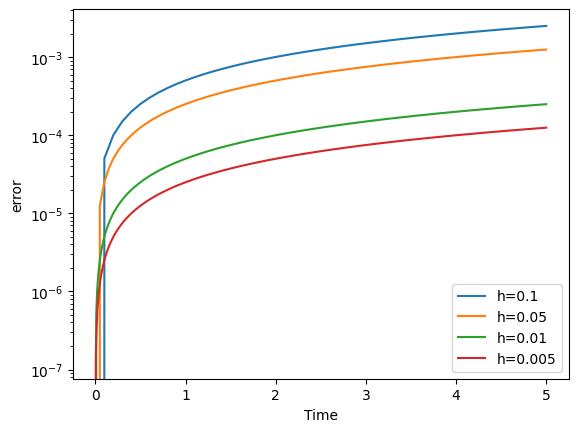

In [26]:
h_values = [0.1, 0.05, 0.01, 0.005]
t_final = 5
N0 = 1000
lambda_val = 0.1

for h in h_values:
    t = np.arange(0, t_final + h, h)
    N = np.zeros(len(t))
    N[0] = N0
    
    for i in range(1, len(t)):
        N[i] = N[i-1] - lambda_val * N[i-1] * h
    
    N_exact = N0 * np.exp(-lambda_val * t)
    error = abs((N - N_exact) / N_exact)
    
    plt.plot(t, error, label=f'h={h}')

plt.xlabel('Time')
plt.ylabel('error')
plt.legend()
plt.yscale('log')
plt.show()

The fractional error decreases as the timestep gets smaller. The error also grows over time for all timestep sizes.

## Acknowledgments


S.E. Clark, last edited 2026

Radioactive Decay problem inspired by "Computational Physics: Second Edition" by Giordano and Nananishi (there are many similar treatments to be found). 

<html>
<body>
Floating point number discussion inspired by the <a target="_blank" rel="noopener noreferrer" href="https://docs.python.org/3/tutorial/floatingpoint.html">Python Tutorial</a>.
</body>
</html>
